<a href="https://colab.research.google.com/github/Larinwa/Flexisaf_Project/blob/main/Object_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install opencv-python

In [32]:
!pip install --upgrade opencv-python==4.7.0.72

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.8/61.8 MB 10.8 MB/s eta 0:00:00
  Attempting uninstall: opencv-python
    Found existing installation: opencv-python 4.13.0.92
    Uninstalling opencv-python-4.13.0.92:
      Successfully uninstalled opencv-python-4.13.0.92


In [2]:
!pip install numpy<2

/bin/bash: line 1: 2: No such file or directory


In [1]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py", line 37, in <module>
    ColabKernelApp.launch_instance()
  File "/usr/local/lib/python3.12/dist-packages/traitlets/config/application.py", line 992, in launch_instance
    app.start()
  File "/usr/local/lib/python3.12/dist-packages/ipykernel/kernelapp.py", line 712, in start
    self.io_loop.start()
  File "/usr/local/lib/python3.12/dist-package

AttributeError: _ARRAY_API not found

ImportError: numpy.core.multiarray failed to import

In [5]:
from google.colab import files
uploaded = files.upload()

Saving face.jpeg to face.jpeg


In [6]:
img = cv2.imread(list(uploaded.keys())[0])
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

In [7]:
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

In [8]:
faces = face_cascade.detectMultiScale(gray, 1.3, 5)

for (x, y, w, h) in faces:
    cv2.rectangle(img, (x,y), (x+w,y+h), (0,255,0), 3)

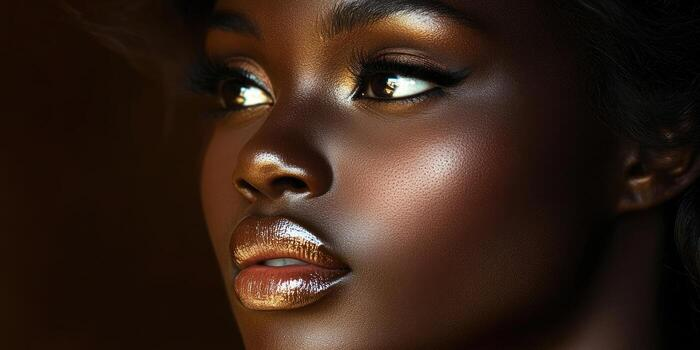

In [9]:
cv2_imshow(img)

In [10]:
modelFile = "https://raw.githubusercontent.com/opencv/opencv/master/samples/dnn/face_detector/deploy.prototxt"
weightsFile = "https://raw.githubusercontent.com/opencv/opencv_3rdparty/master/res10_300x300_ssd_iter_140000_fp16.caffemodel"

In [24]:
!wget -O res10_300x300_ssd_iter_140000.caffemodel \
https://github.com/opencv/opencv_3rdparty/raw/dnn_samples_face_detector_20170830/res10_300x300_ssd_iter_140000.caffemodel

--2026-03-13 09:27:42--  https://github.com/opencv/opencv_3rdparty/raw/dnn_samples_face_detector_20170830/res10_300x300_ssd_iter_140000.caffemodel
Resolving github.com (github.com)... 140.82.113.3
Connecting to github.com (github.com)|140.82.113.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/opencv/opencv_3rdparty/dnn_samples_face_detector_20170830/res10_300x300_ssd_iter_140000.caffemodel [following]
--2026-03-13 09:27:42--  https://raw.githubusercontent.com/opencv/opencv_3rdparty/dnn_samples_face_detector_20170830/res10_300x300_ssd_iter_140000.caffemodel
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.111.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10666211 (10M) [application/octet-stream]
Saving to: ‘res10_300x300_ssd_iter_140000.caffem

In [25]:
!wget -O deploy.prototxt \
https://raw.githubusercontent.com/opencv/opencv/master/samples/dnn/face_detector/deploy.prototxt

--2026-03-13 09:28:00--  https://raw.githubusercontent.com/opencv/opencv/master/samples/dnn/face_detector/deploy.prototxt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.110.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 28104 (27K) [text/plain]
Saving to: ‘deploy.prototxt’

deploy.prototxt     100%[===================>]  27.45K  --.-KB/s    in 0.001s  

2026-03-13 09:28:00 (18.9 MB/s) - ‘deploy.prototxt’ saved [28104/28104]



In [26]:
!ls -lh res10_300x300_ssd_iter_140000.caffemodel

-rw-r--r-- 1 root root 11M Mar 13 09:27 res10_300x300_ssd_iter_140000.caffemodel


In [27]:
net = cv2.dnn.readNetFromCaffe("deploy.prototxt", "res10_300x300_ssd_iter_140000_fp16.caffemodel")

In [13]:
from google.colab import files
uploaded = files.upload()

Saving face2.jpg to face2.jpg


In [28]:
img = cv2.imread(list(uploaded.keys())[0])
(h, w) = img.shape[:2]

In [29]:
blob = cv2.dnn.blobFromImage(cv2.resize(img, (300, 300)), 1.0,
                             (300, 300), (104.0, 177.0, 123.0))

In [30]:
net.setInput(blob)

In [31]:
detections = net.forward()
for i in range(detections.shape[2]):
    confidence = detections[0, 0, i, 2]
    if confidence > 0.5:
        box = detections[0, 0, i, 3:7] * np.array([w, h, w, h])
        (startX, startY, endX, endY) = box.astype("int")
        cv2.rectangle(img, (startX, startY), (endX, endY), (0, 255, 0), 3)
        cv2.putText(img, f"{confidence*100:.1f}%", (startX, startY-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,255,0), 2)

error: OpenCV(4.13.0) /io/opencv/modules/dnn/src/layers/batch_norm_layer.cpp:49: error: (-215:Assertion failed) blobs.size() >= 2 in function 'BatchNormLayerImpl'


In [17]:
net = cv2.dnn.readNetFromCaffe("deploy.prototxt", "res10_300x300_ssd_iter_140000.caffemodel")

error: OpenCV(4.13.0) /io/opencv/modules/dnn/src/caffe/caffe_io.cpp:1144: error: (-2:Unspecified error) FAILED: fs.is_open(). Can't open "res10_300x300_ssd_iter_140000.caffemodel" in function 'ReadProtoFromBinaryFile'


In [16]:
net.setInput(blob)
detections = net.forward()

error: OpenCV(4.13.0) /io/opencv/modules/dnn/src/layers/batch_norm_layer.cpp:49: error: (-215:Assertion failed) blobs.size() >= 2 in function 'BatchNormLayerImpl'
